# Regresión Logística

In [1]:
#importar librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#importar dataset
titanic = pd.read_csv('titanic.csv').reindex(columns = ["Sex", "Age", "Pclass", "Survived"])
titanic.head()
titanic.isna().sum()
titanic = titanic.dropna()
titanic.isna().sum()

Sex         0
Age         0
Pclass      0
Survived    0
dtype: int64

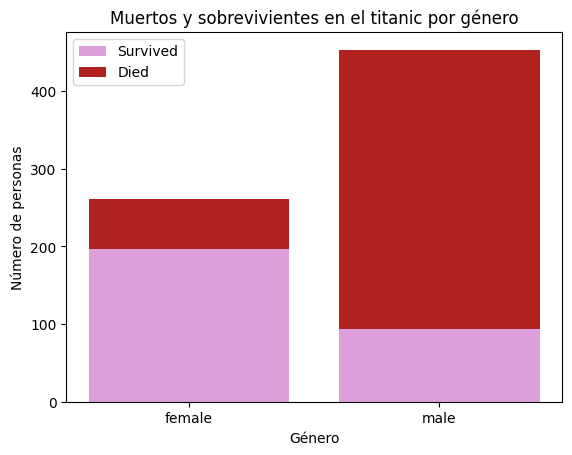

In [3]:
cont_sur_age=titanic.groupby(["Survived","Sex"]).count().reset_index()
cont_sur_age
cont_1=cont_sur_age[cont_sur_age['Survived']!=0]
cont_1.head() #sobrevivieron
cont_0=cont_sur_age[cont_sur_age['Survived']!=1]
cont_0.head() #murieron
plt.bar(cont_1["Sex"],cont_1["Pclass"],label="Survived",color="plum")
plt.bar(cont_0["Sex"],cont_0["Pclass"],label="Died",bottom=cont_1["Pclass"],color="firebrick")
plt.legend()
plt.title("Muertos y sobrevivientes en el titanic por género")
plt.xlabel("Género")
plt.ylabel("Número de personas")
plt.show()

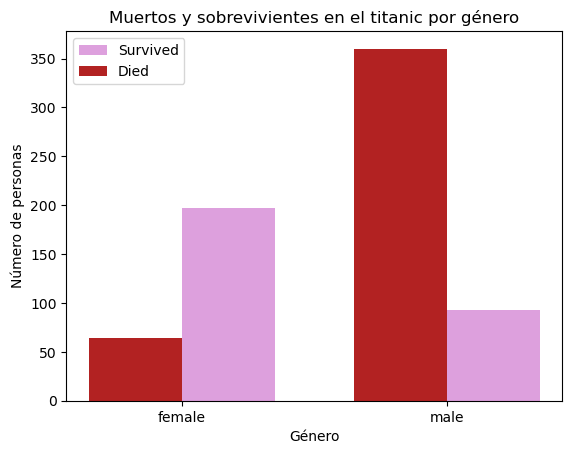

In [4]:
width=0.35 # ancho de barras
labels=cont_1["Sex"]
x=np.arange(len(labels))
#pintando las barras
plt.bar(x+width/2,cont_1["Pclass"],width,label="Survived",color="plum")
plt.bar(x-width/2,cont_0["Pclass"],width,label="Died",color="firebrick")
# cambiando el eje x a los paises
plt.xticks(x,labels)
#incluyendo leyend
plt.legend()
plt.title("Muertos y sobrevivientes en el titanic por género")
plt.xlabel("Género")
plt.ylabel("Número de personas")
plt.show()

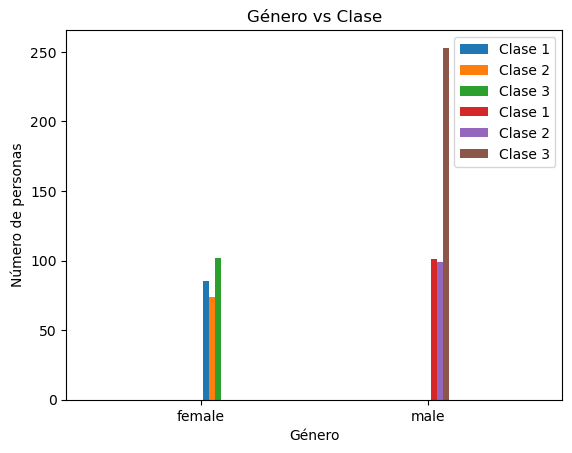

In [5]:
fem_class1=titanic[(titanic['Sex']=="female") & (titanic['Pclass']==1)]
fem_class2=titanic[(titanic['Sex']=="female") & (titanic['Pclass']==2)]
fem_class3=titanic[(titanic['Sex']=="female") & (titanic['Pclass']==3)]
male_class1=titanic[(titanic['Sex']=="male") & (titanic['Pclass']==1)]
male_class2=titanic[(titanic['Sex']=="male") & (titanic['Pclass']==2)]
male_class3=titanic[(titanic['Sex']=="male") & (titanic['Pclass']==3)]
plt.hist([fem_class1["Sex"],fem_class2["Sex"],fem_class3["Sex"]],
 label=["Clase 1","Clase 2","Clase 3"],stacked=False)
plt.hist([male_class1["Sex"],male_class2["Sex"],male_class3["Sex"]],label=["Clase 1","Clase 2","Clase 3"],stacked=False)
plt.legend()
plt.title("Género vs Clase")
plt.xlabel("Género")
plt.ylabel("Número de personas")
plt.show()

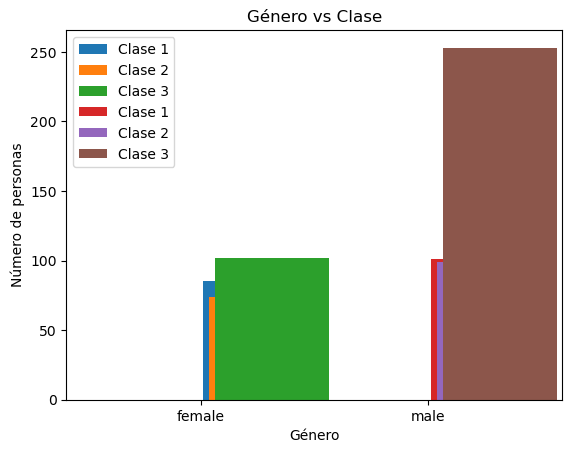

In [6]:
plt.hist([fem_class1["Sex"],fem_class2["Sex"],fem_class3["Sex"]],
 label=["Clase 1","Clase 2","Clase 3"],
 width=0.5,stacked=False)
plt.hist([male_class1["Sex"],male_class2["Sex"],male_class3["Sex"]],label=["Clase 1","Clase 2","Clase 3"],
 width=0.5,stacked=False)
plt.legend()
plt.title("Género vs Clase")
plt.xlabel("Género")
plt.ylabel("Número de personas")
plt.show()

In [7]:
titanic.head()

,Sex,Age,Pclass,Survived
0,male,22.0,3,0
1,female,38.0,1,1
2,female,26.0,3,1
3,female,35.0,1,1
4,male,35.0,3,0


In [4]:
import sklearn
import sklearn.preprocessing
#from sklearn.preprocessing import imputer
#imputer = Imputer(missing_values  = "NaN", strategy = "mean", axis = 0)
#imputer = imputer.fit(titanic["Age"].values)

In [5]:
titanic_df = titanic.reindex(columns = ["Age", "Survived"])

In [6]:
X = titanic_df.iloc[:, :-1].values
y = titanic_df.iloc[:, -1].values

In [7]:
titanic_df = titanic_df[-pd.isnull(titanic_df["Age"])]
#len(titanic_df)
titanic_df.reset_index().reindex(columns = ["Age", "Survived"])

,Age,Survived
0,22.0,0
1,38.0,1
2,26.0,1
3,35.0,1
4,35.0,0
...,...,...
709,39.0,0
710,27.0,0
711,19.0,1
712,26.0,1


In [8]:
#Regresión logística con una variable independiente. 
import scipy.stats as stats
# H0: las dos variables son independientes vs H0: las dos variables son dependientes
#realice la prueba chi-cuadrado de independencia
stats.chi2_contingency(titanic_df[["Age", "Survived"]])

Chi2ContingencyResult(statistic=1240.3871364335314, pvalue=4.550051369091589e-31, dof=713, expected_freq=array([[21.70318914,  0.29681086],
       [38.47383528,  0.52616472],
       [26.63573212,  0.36426788],
       ...,
       [19.73017194,  0.26982806],
       [26.63573212,  0.36426788],
       [31.56827511,  0.43172489]]))

In [9]:
X = titanic_df.iloc[:, :-1].values
y = titanic_df.iloc[:, -1].values

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [13]:
print("Intercept:", classifier.intercept_)
print("Coeficiente Age:",classifier.coef_.flatten()[0] )
print("Accuracy de entrenamiento:", classifier.score(X_train, y_train))

Intercept: [-0.40899886]
Coeficiente Age: -0.18652305614804487
Accuracy de entrenamiento: 0.6


In [14]:
predicciones = classifier.predict_proba(X_test)
predicciones = pd.DataFrame(predicciones, columns = classifier.classes_)
predicciones

,0,1
0,0.595600,0.404400
1,0.661660,0.338340
2,0.509538,0.490462
3,0.620170,0.379830
4,0.589377,0.410623
...,...,...
174,0.554686,0.445314
175,0.614080,0.385920
176,0.554686,0.445314
177,0.583125,0.416875


In [15]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.weightstats import ttest_ind

In [16]:
X_train = sm.add_constant(X_train, prepend=True)
modelo = sm.Logit(endog=y_train, exog=X_train,)
modelo = modelo.fit()
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.668857
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  535
Model:                          Logit   Df Residuals:                      533
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Mar 2025   Pseudo R-squ.:                0.006173
Time:                        20:27:27   Log-Likelihood:                -357.84
converged:                       True   LL-Null:                       -360.06
Covariance Type:            nonrobust   LLR p-value:                   0.03500
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4092      0.089     -4.613      0.000      -0.583      -0.235
x1            -0.1881      0.

In [17]:
predicciones = modelo.predict(exog = X_train)
predicciones[:4]

array([0.47149918, 0.35248385, 0.42650347, 0.41383532])

In [18]:
# Clasificación predicha
# ==============================================================================
clasificacion = np.where(predicciones<0.5, 0, 1)
clasificacion

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [19]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[103   0]
 [ 76   0]]


0.5754189944134078

### Árbol de decisión

In [21]:
import pandas as pd
df = pd.get_dummies(data=titanic, drop_first=True) #convertimos nuestras variables a tipo númerico
explicativas = df.drop(columns='Survived')
objetivo = df.Survived
objetivo
print(explicativas)


      Age  Pclass  Sex_male
0    22.0       3      True
1    38.0       1     False
2    26.0       3     False
3    35.0       1     False
4    35.0       3      True
..    ...     ...       ...
885  39.0       3     False
886  27.0       2      True
887  19.0       1     False
889  26.0       1      True
890  32.0       3      True

[714 rows x 3 columns]


In [22]:
from sklearn.tree import DecisionTreeClassifier #utilizamos la librería sklearn para generar el árbol de decisión

In [23]:
model = DecisionTreeClassifier(max_depth=3) #corta la profundidad del modelo con max_depth
model.fit(X=explicativas, y=objetivo)

DecisionTreeClassifier(max_depth=3)

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

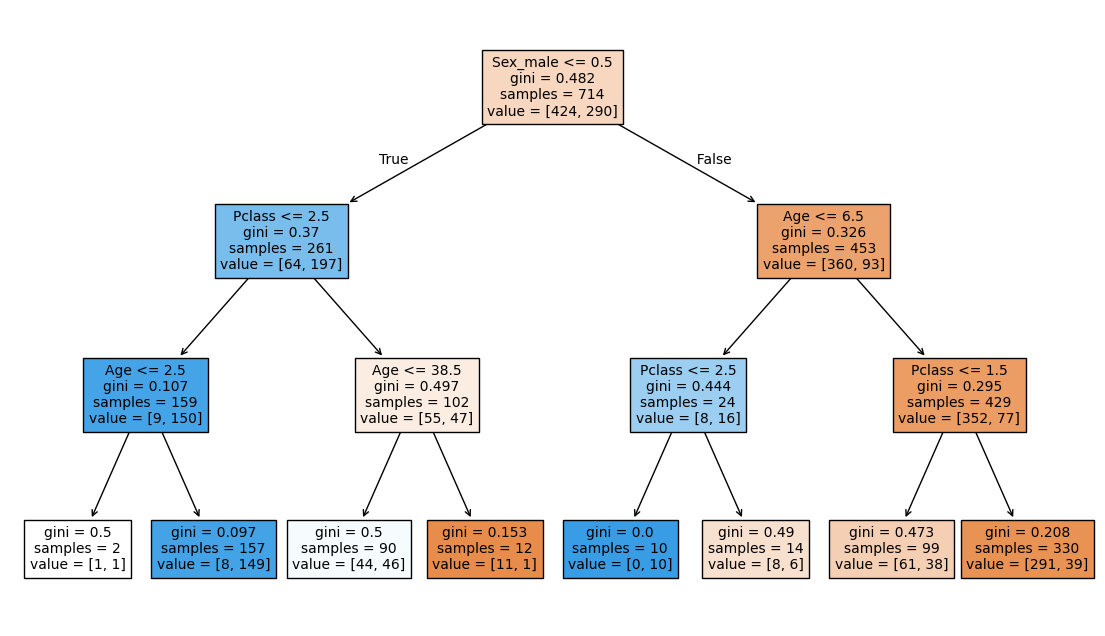

In [25]:
plt.figure(figsize=(14,8))
plot_tree(decision_tree=model, feature_names=explicativas.columns, filled=True, fontsize=10);

##  ¿Qué tan acertado es el modelo?

In [26]:
a = explicativas.sample()
a

,Age,Pclass,Sex_male
503,37.0,3,False


In [27]:
model.predict_proba(a) 
y_pred=model.predict(explicativas)
y_pred

df['pred'] = y_pred

In [28]:
df['Survived'] == df['pred']

0       True
1       True
2       True
3       True
4       True
       ...  
885     True
886     True
887     True
889    False
890     True
Length: 714, dtype: bool

In [29]:
Aciertos = (df['Survived'] == df['pred']).sum()
Aciertos
#el número total de aciertos 

577

In [30]:
Total = 714
Total
#el número total de la muestra

714

In [31]:
Asertividad = Aciertos/Total
Asertividad

0.8081232492997199